In [2]:
import os
import pydicom
import numpy as np
import cv2
from tqdm import tqdm

# Kaggle Dataset Path
INPUT_PATH = "/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/train"
OUTPUT_PATH = "/kaggle/working/train_png"

os.makedirs(OUTPUT_PATH, exist_ok=True)

def dicom_to_png(dicom_path, output_path):
    dicom = pydicom.dcmread(dicom_path)
    image = dicom.pixel_array.astype(np.float32)

    # Normalize to 0–255
    image -= np.min(image)
    if np.max(image) != 0:
        image /= np.max(image)
    image *= 255.0

    image = image.astype(np.uint8)
    cv2.imwrite(output_path, image)

# Convert only first 50 images for testing (IMPORTANT)
files = [f for f in os.listdir(INPUT_PATH) if f.endswith(".dicom")]

print("Total DICOM files found:", len(files))

for file in tqdm(files[:50]):   # limit for testing
    dicom_path = os.path.join(INPUT_PATH, file)
    output_path = os.path.join(OUTPUT_PATH, file.replace(".dicom", ".png"))
    dicom_to_png(dicom_path, output_path)

print("Sample conversion completed.")


Total DICOM files found: 15000


100%|██████████| 50/50 [01:00<00:00,  1.21s/it]

Sample conversion completed.


In [3]:
print(os.listdir("/kaggle/working/train_png")[:5])


['0d6231a3ed3eefc3ba60353b9ad00816.png', '68335ee73e67706aa59b8b55b54b11a4.png', '160bb47c3022a18a9e106c8794ddd4a0.png', '80974692ba1a204134e0a5ef2b5dd43c.png', 'ba4a00ea7764b5ee772792a50531e9e7.png']


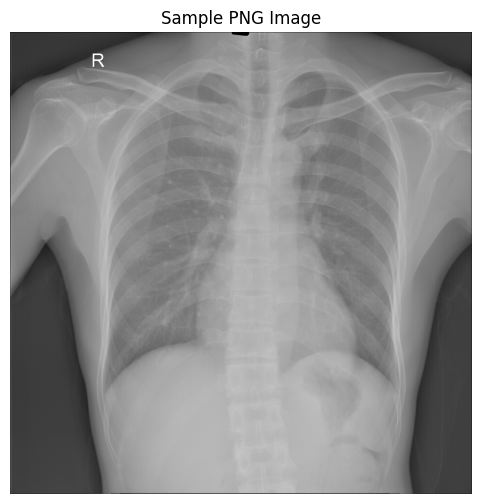

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(img, cmap="gray")
plt.title("Sample PNG Image")
plt.axis("off")
plt.show()


# First 50 Images Conversion Complited 

In [8]:
import os
import pydicom
import numpy as np
import cv2
from tqdm import tqdm

INPUT_PATH = "/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/train"
OUTPUT_PATH = "/kaggle/working/train_png"

os.makedirs(OUTPUT_PATH, exist_ok=True)

def dicom_to_png(dicom_path, output_path):
    dicom = pydicom.dcmread(dicom_path)
    image = dicom.pixel_array.astype(np.float32)

    # Normalize to 0–255
    image -= np.min(image)
    if np.max(image) != 0:
        image /= np.max(image)
    image *= 255.0

    image = image.astype(np.uint8)
    cv2.imwrite(output_path, image)

# Get all dicom files
files = [f for f in os.listdir(INPUT_PATH) if f.endswith(".dicom")]

print("Total DICOM files found:", len(files))
print("Converting images...")

for file in tqdm(files[:4000]):
    dicom_path = os.path.join(INPUT_PATH, file)
    output_path = os.path.join(OUTPUT_PATH, file.replace(".dicom", ".png"))
    dicom_to_png(dicom_path, output_path)

print("Images converted successfully.")


Total DICOM files found: 15000
Converting images...


 26%|██▌       | 1046/4000 [20:00<56:29,  1.15s/it]  


KeyboardInterrupt: 

In [10]:
import os
import cv2

png_folder = "/kaggle/working/train_png"

if os.path.exists(png_folder) and len(os.listdir(png_folder)) > 0:
    img_file = os.listdir(png_folder)[0]
    img = cv2.imread(os.path.join(png_folder, img_file), cv2.IMREAD_GRAYSCALE)
    print("Image loaded successfully:", img.shape)
else:
    print("PNG folder not found or empty.")


Image loaded successfully: (3072, 3072)


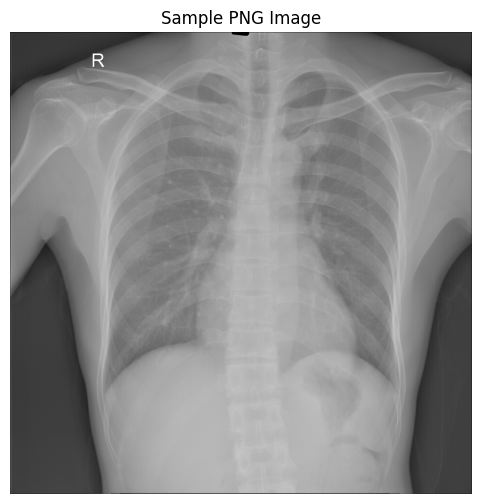

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(img, cmap="gray")
plt.title("Sample PNG Image")
plt.axis("off")
plt.show()


In [12]:
import pandas as pd

csv_path = "/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/train.csv"
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
df.head()

Shape: (67914, 8)


,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max
0,50a418190bc3fb1ef1633bf9678929b3,No finding,14,R11,NaN,NaN,NaN,NaN
1,21a10246a5ec7af151081d0cd6d65dc9,No finding,14,R7,NaN,NaN,NaN,NaN
2,9a5094b2563a1ef3ff50dc5c7ff71345,Cardiomegaly,3,R10,691.0,1375.0,1653.0,1831.0
3,051132a778e61a86eb147c7c6f564dfe,Aortic enlargement,0,R10,1264.0,743.0,1611.0,1019.0
4,063319de25ce7edb9b1c6b8881290140,No finding,14,R10,NaN,NaN,NaN,NaN
